# Evaluating an orientation model on the RIANN IMU benchmarks

This notebook walks through scoring an **orientation-estimation** model with
IdentiBench. The task: given an IMU stream (accelerometer + gyroscope), output
the sensor's orientation as a unit quaternion at every sample. IdentiBench
downloads the data, runs your model over each test sequence, and reports the
**inclination (tilt) error in degrees**.

The model below is a deliberately naive baseline — a **gyroscope strap-down
integrator**. It integrates angular velocity into orientation and ignores the
accelerometer entirely, so it has no gravity reference to correct itself: small
per-sample errors accumulate and the estimate *drifts* over time. That drift is
exactly what we'll visualize at the end, and it's the floor that any real model
(a complementary filter, a neural network, …) should beat.

To plug in your own model, replace `build_model` — the interface is identical.

> **Data download.** The first run fetches the dataset (BROAD, ~0.8 GB) from its
> original public source and caches it under `~/.identibench_data` (override with
> the `IDENTIBENCH_DATA_ROOT` environment variable). Later runs reuse the cache.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import identibench as idb

## A baseline model: gyroscope strap-down integration

IdentiBench calls `build_model(context)` once and expects it to return a
callable `model(u, y_init, attrs) -> (N, 4)` that maps an input sequence to a
quaternion track. The input columns `u` follow the standardized IMU layout
`[acc_x, acc_y, acc_z, gyr_x, gyr_y, gyr_z, dt]`, so the gyroscope is columns
`3:6` and the per-sample timestep is column `6`.

Each step rotates the running orientation by the small rotation the gyroscope
implies over `dt`, then renormalizes to keep the quaternion on the unit sphere.

In [2]:
def _quat_from_rotvec(rv: np.ndarray) -> np.ndarray:
    """Unit quaternion [w, x, y, z] of a small rotation vector (axis * angle)."""
    angle = np.linalg.norm(rv)
    if angle < 1e-12:
        return np.array([1.0, 0.0, 0.0, 0.0])
    axis = rv / angle
    s = np.sin(angle / 2.0)
    return np.array([np.cos(angle / 2.0), axis[0] * s, axis[1] * s, axis[2] * s])


def _qmult(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Hamilton product a ⊗ b of two [w, x, y, z] quaternions."""
    aw, ax, ay, az = a
    bw, bx, by, bz = b
    return np.array(
        [
            aw * bw - ax * bx - ay * by - az * bz,
            aw * bx + ax * bw + ay * bz - az * by,
            aw * by - ax * bz + ay * bw + az * bx,
            aw * bz + ax * by - ay * bx + az * bw,
        ]
    )


def build_model(context):
    """Return a callable ``model(u, y_init, attrs) -> (N, 4)`` quaternion array.

    The baseline integrates the gyroscope (``u`` columns 3:6) over the per-sample
    timestep (column 6), starting from the identity orientation. It never looks at
    the accelerometer, so nothing pulls it back toward gravity — hence the drift.
    """

    def model(u, y_init, attrs):
        gyr = u[:, 3:6]
        dt = u[:, 6]
        n = len(u)
        q = np.empty((n, 4))
        q[0] = [1.0, 0.0, 0.0, 0.0]
        for t in range(1, n):
            dq = _quat_from_rotvec(gyr[t] * dt[t])
            q[t] = _qmult(q[t - 1], dq)
            q[t] /= np.linalg.norm(q[t])
        return q

    return model

## Run the benchmark

`BenchmarkBROAD_Inclination` is a single source — a good first target.
(`BenchmarkEuRoC_Inclination` is an equally good, lighter-weight alternative;
pick whichever source you like — the interface is the same.) The headline metric
is the **faithful RIANN number**: the first-sample-aligned inclination error
(the estimate is rotated to match ground truth at the first sample, removing
the fixed offset between the IMU's gravity frame and the optical reference
frame), restricted to *moving* segments via each file's `movement_mask`,
sample-pooled across all sources, and reported as an RMSE.

In [3]:
result = idb.run_benchmark(idb.BenchmarkBROAD_Inclination, build_model)

print(f"metric ({result['metric_name']}): {result['metric_score']:.3f} deg")
print("(first-sample aligned, masked, sample-pooled)")

metric (aligned_inclination_rmse_deg): 19.581 deg
(first-sample aligned, unmasked)


## Per-source scores

`result["test_sets"]` carries the per-source breakdown: each named test set
(= source dataset) is scored as one sample pool with the masked inclination
RMSE and its 99th-percentile worst case, plus the pooled `"all"` set that is
the headline.

In [4]:
for set_name, metric_scores in sorted(result["test_sets"].items()):
    for metric_name, val in sorted(metric_scores.items()):
        print(f"  {set_name + '/' + metric_name:40s} {val:7.3f} deg")

  Myon/incl_p99_deg                 72.030 deg
  Myon/incl_rmse_deg                22.861 deg
  all/incl_p99_deg                  72.030 deg
  all/incl_rmse_deg                 22.861 deg


## Visualizing the drift

A single RMSE hides *how* the error behaves. The strap-down integrator's defining
trait is that error grows roughly monotonically as small mistakes accumulate —
so let's plot the per-sample tilt error along the first test sequence.

The result dict carries only scalar scores, so we run the model over the first
test sequence ourselves. `identibench.metrics._aligned_inclination_rad` returns
the same per-sample tilt error (in radians) that the headline RMSE aggregates —
using it here keeps the plot consistent with the reported number.

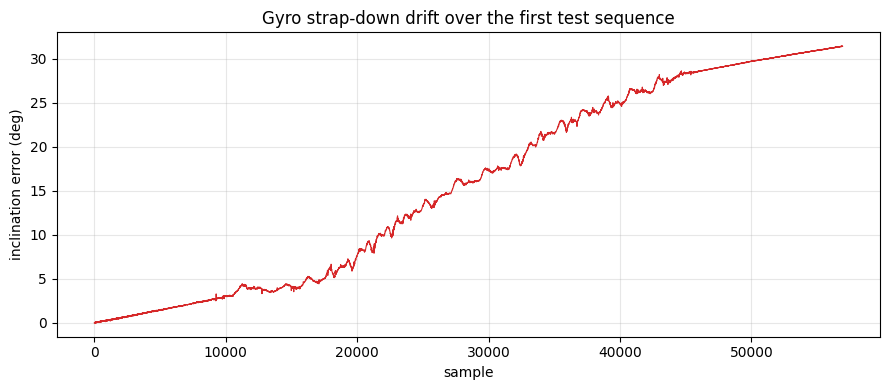

In [5]:
from identibench.metrics import _aligned_inclination_rad

context = idb.TrainingContext(idb.BenchmarkBROAD_Inclination, hyperparameters={}, seed=0)
seq = next(context.get_test_sequences())
model = build_model(context)
y_pred, y_true = model(seq.u, seq.y[:0], seq.attrs), seq.y
incl_deg = _aligned_inclination_rad(y_pred, y_true) * 180.0 / np.pi
sample = np.arange(len(incl_deg))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sample, incl_deg, lw=0.8, color="tab:red")
ax.set_xlabel("sample")
ax.set_ylabel("inclination error (deg)")
ax.set_title("Gyro strap-down drift over the first test sequence")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

The upward trend is the integrator drifting: with no accelerometer correction,
the estimate wanders further from ground truth the longer it runs. A model that
fuses the accelerometer's gravity direction (a complementary/Kalman filter, or a
learned estimator like RIANN) keeps this curve flat — that's the gap to close.

## Your own model, and the full protocol

To evaluate a different estimator, swap the body of `model(...)` for your own
forward pass — any framework works, as long as it returns an `(N, 4)` quaternion
array. The benchmark harness is unchanged.

To reproduce the full RIANN cross-dataset protocol (every source pooled into one
run) instead of a single source, swap the spec:

```python
result = idb.run_benchmark(idb.BenchmarkRIANN_Inclination, build_model)
```